Artifact Name: run_cuchpasy_model:v12


wandb:   1 of 1 files downloaded.  


Transferred 208/208 items from pretrained weights
AUC: 0.9686


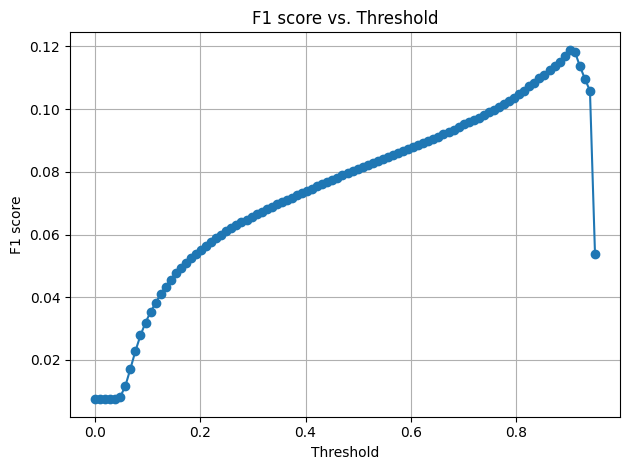

Artifact Name: run_e9q1xmrb_model:v0


wandb:   1 of 1 files downloaded.  


Transferred 208/208 items from pretrained weights
AUC: 0.7420


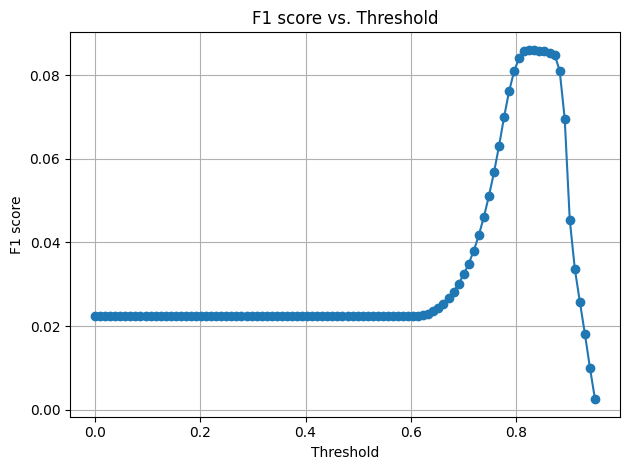

Artifact Name: run_bro0opv0_model:v3


wandb:   1 of 1 files downloaded.  


Transferred 208/208 items from pretrained weights
AUC: 0.6789


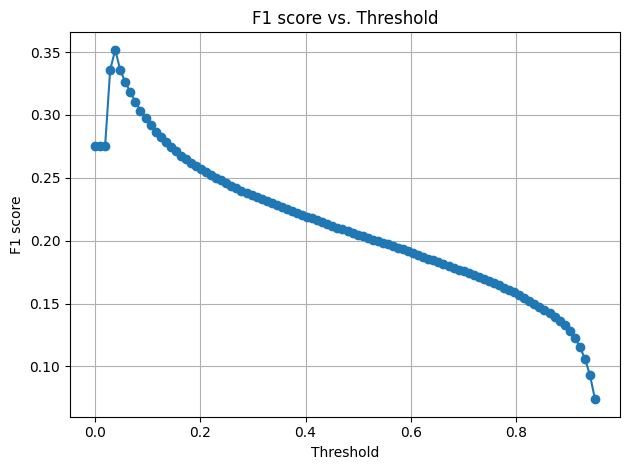

Artifact Name: run_kefp492k_model:v9


wandb:   1 of 1 files downloaded.  


Transferred 208/208 items from pretrained weights
AUC: 0.5032


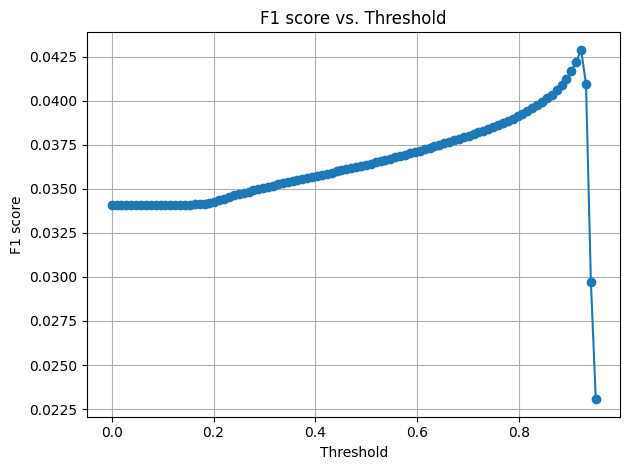

Artifact Name: run_0z3hxruy_model:v3


wandb:   1 of 1 files downloaded.  


Transferred 208/208 items from pretrained weights
AUC: 0.7562


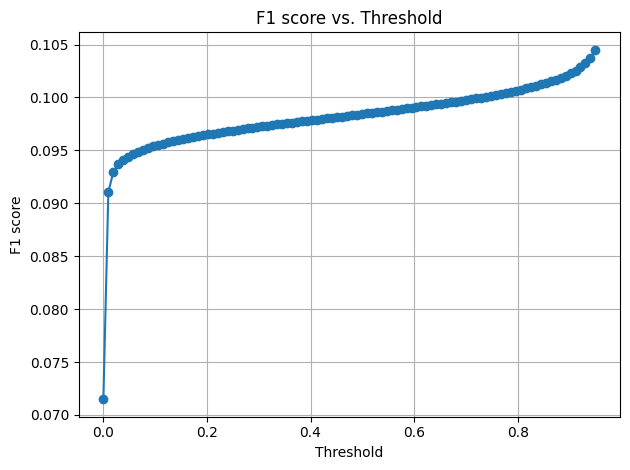

Artifact Name: run_ton005pd_model:v23


wandb:   1 of 1 files downloaded.  


Transferred 208/208 items from pretrained weights
AUC: 0.7734


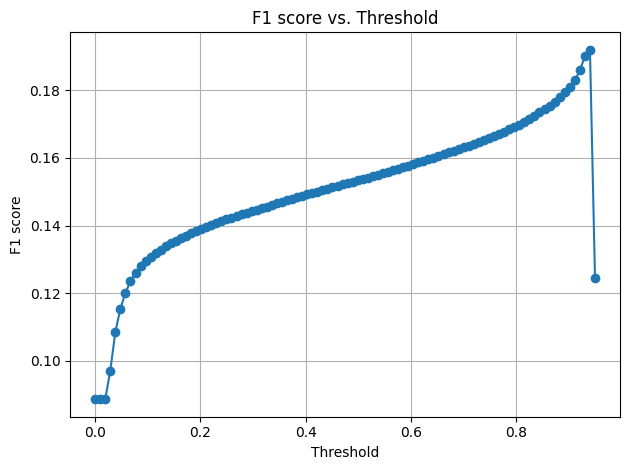

Artifact Name: run_49zjgmfu_model:v3


wandb:   1 of 1 files downloaded.  


Transferred 208/208 items from pretrained weights


In [ ]:
import wandb
from pathlib import Path
from torchmetrics.classification import AUROC
from landslide.data import LandslideDataset, dataloader, dataset_read_config
from landslide.model import init_model
from landslide.metrics import BinaryConfusionMatrix
from landslide.torch_utils import intersect_dicts
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

ROOT = Path("../")
DEVICE = "mps:0"
ENTITY = "gianluca-calo11"  # Replace with your entity name
PROJECT = "landslide"  # Replace with your project name


def load_model(model: nn.Module, weights: Path, verbose: bool = True) -> nn.Module:
    from safetensors.torch import load_file

    checkpoint = (
        torch.load(weights, map_location="cpu", weights_only=False)
        if not weights.name.endswith(".safetensors")
        else load_file(weights, device="cpu")
    )
    checkpoint = checkpoint["model"] if "model" in checkpoint else checkpoint
    csd = intersect_dicts(checkpoint, model.state_dict())  # intersect
    model.load_state_dict(csd, strict=False)  # load
    if verbose:
        print(f"Transferred {len(csd)}/{len(model.state_dict())} items from pretrained weights")
    return model


def run_test(model_name: str, dataset: Path, checkpoint: Path, device: str = "cpu"):
    metric = AUROC(task="binary")
    data = dataset_read_config(dataset / "config.yaml")
    model = init_model(model_name, data)
    model = load_model(model, checkpoint)
    device = torch.device(device)
    tresholds = torch.linspace(0.0, 0.95, 100)
    confmats = [BinaryConfusionMatrix(threshold=t) for t in tresholds]
    fold, mean, std = data["test"], data["mean"], data["std"]
    test_set = LandslideDataset(
        fold,
        image_sz=512,
        mask_sz=512,
        mean=mean,
        std=std,
        do_normalize=True,
    )
    test_loader = dataloader(
        test_set,
        batch_size=16,
        workers=0,
        shuffle=False, mode="test")

    model = model.to(device)
    model.eval()
    with torch.inference_mode():
        for imgs, masks in test_loader:
            imgs = imgs.to(device, non_blocking=True)
            # masks = masks.to(device, non_blocking=True)
            logits = model(imgs).cpu()
            outputs = F.interpolate(F.sigmoid(logits), size=masks.shape[-2:], mode="bilinear", align_corners=False)
            metric.update(outputs.flatten(), masks.flatten())
            for confmat in confmats:
                confmat.update(outputs, masks)
        
        auc_score = metric.compute()
        print(f"AUC: {auc_score:.4f}")
        f1_scores = [cm.f1 for cm in confmats]
        thresholds = [cm.threshold for cm in confmats]

        plt.figure()
        plt.plot(thresholds, f1_scores, marker="o")
        plt.xlabel("Threshold")
        plt.ylabel("F1 score")
        plt.title("F1 score vs. Threshold")
        plt.grid(True)
        plt.tight_layout()
        plt.show()


def download_weights_best(run) -> Path:
    """
    Downloads the best model artifact from a given run.
    """
    for artifact in run.logged_artifacts():
        if artifact.type == 'model' and 'best' in artifact.aliases:
            print(f"Artifact Name: {artifact.name}")
            return Path(artifact.download()) / "last.pth"
    return None


api = wandb.Api()
runs = api.runs(f"{ENTITY}/{PROJECT}")  # Replace with your entity and project name
for run in runs:
    # print(f"Run Name: {run.name}, Run ID: {run.id}, Config: {run.config}")
    model = run.config['model']
    dataset = ROOT.joinpath(run.config['dataset'])
    checkpoint = download_weights_best(run)
    run_test(model, dataset, checkpoint, device=DEVICE)



## Errors

In [ ]:
from pathlib import Path
from landslide.data import get_images, img_to_mask
from PIL import Image
import cv2


path = Path("../data/raw/land-anomalies")
for location in path.iterdir():
    if not location.is_dir():
        continue
    imgs = get_images(location / "segmentation_512_512" / "img")
    imgs = list(map(Path, imgs))
    masks = list(map(img_to_mask, imgs))

    for img, mask in zip(imgs, masks):

        loaded_img = Image.open(img)
        loaded_mask = Image.open(mask)
        # if loaded_img.mode != "RGB":
        #     print(f"Image {img} is not RGB.", "it is", loaded_img.mode)
        if loaded_mask.mode != "L":
            print(f"Mask {mask} is not L (grayscale).", "it is", loaded_mask.mode)


Mask ../data/raw/land-anomalies/Miglionico_5cm/segmentation_512_512/mask/patch_0_0_0.tif is not L (grayscale). it is 1
Mask ../data/raw/land-anomalies/Miglionico_5cm/segmentation_512_512/mask/patch_1_512_0.tif is not L (grayscale). it is 1
Mask ../data/raw/land-anomalies/Miglionico_5cm/segmentation_512_512/mask/patch_2_1024_0.tif is not L (grayscale). it is 1
Mask ../data/raw/land-anomalies/Miglionico_5cm/segmentation_512_512/mask/patch_3_0_512.tif is not L (grayscale). it is 1
Mask ../data/raw/land-anomalies/Miglionico_5cm/segmentation_512_512/mask/patch_4_512_512.tif is not L (grayscale). it is 1
Mask ../data/raw/land-anomalies/Miglionico_5cm/segmentation_512_512/mask/patch_5_1024_512.tif is not L (grayscale). it is 1
Mask ../data/raw/land-anomalies/Bella3_5cm/segmentation_512_512/mask/patch_0_0_0.tif is not L (grayscale). it is 1
Mask ../data/raw/land-anomalies/Bella3_5cm/segmentation_512_512/mask/patch_10_5120_0.tif is not L (grayscale). it is 1
Mask ../data/raw/land-anomalies/Bell

In [24]:
import torch
import torch
import numpy as np
from sklearn.metrics import roc_auc_score

def auc_segmentation(pred_probs, gt_masks, *, eps: float = 1e-7):
    """
    Compute ROC-AUC for a batch of segmentation maps.

    Parameters
    ----------
    pred_probs : torch.Tensor | np.ndarray
        Predicted foreground probabilities with shape (N, H, W) **or**
        (N, 1, H, W).  Values must be in [0, 1].

    gt_masks : torch.Tensor | np.ndarray
        Ground-truth binary masks with identical shape to `pred_probs`
        (foreground = 1, background = 0).

    eps : float, optional
        Small value to avoid edge-case errors when a batch is entirely one class.

    Returns
    -------
    float
        The ROC-AUC computed over **all pixels in the batch**.  NaNs produced
        by all-positive or all-negative ground truth maps are replaced by 0.5
        (chance level).

    Notes
    -----
    * For a *multi-class* problem you can call this once per class (one-vs-all)
      or switch to `torchmetrics.AUROC(task="multiclass", num_classes=K)`.
    * If you store masks as `bool`, convert with `.float()` first.
    """
    # Move data to CPU & NumPy
    if isinstance(pred_probs, torch.Tensor):
        pred_probs = pred_probs.detach().cpu().numpy()
    if isinstance(gt_masks, torch.Tensor):
        gt_masks = gt_masks.detach().cpu().numpy()

    # Remove singleton channel dim, flatten batch and spatial dims
    pred_flat = pred_probs.reshape(-1)
    gt_flat   = gt_masks.reshape(-1)

    # Guard against edge cases where ground truth is all 0 or all 1
    pos_ratio = gt_flat.mean()
    if pos_ratio < eps or pos_ratio > 1 - eps:
        return 0.5  # undefined AUC → chance

    return roc_auc_score(gt_flat, pred_flat)

iouv = torch.linspace(0, 0.95, 20)

pred_mask = torch.rand(1, 1, 512, 512)
targ_mask = torch.randint(0, 2, (1, 1, 512, 512)).float()  # binary mask


auc_segmentation(pred_mask, targ_mask)  # should be around 0.5 since both are random




0.5009438539944574